# VoI accumulation per robot

This notebook illustrates how the value of information (VoI) is accumulated by each robot during a run, using `WBF_Score_VoI` and its attribution API (DESIGN-VOI.md, Section 4).

- **`WBF_Score_VoI`** computes the four VoI variants at every scoring event: absolute, expected, cost of ignorance and estimator-based. It also emits `"voi-credits"`, which split the change since the previous event into two parts:
  - **discovery credits:** the change at each newly observed cell, credited to the robot that observed it first, at that timestep (from `estimator.record`);
  - **update terms** (`robot = None`): the change at all other cells, caused by the estimator's refit spreading the observations to their neighborhood.
- **`voi_credits(results, variant)`** turns these into one array per robot, indexed by timestep, plus a `None` row for the update terms.

The scenario is similar to the ObservationRecord notebook: a Miniberry-10 farm with three robots whose paths intersect. Here alpha drives along a tomato row (y=8), because the row y=5 lies between the two fields.

In [1]:
import sys
import tempfile
sys.path.append("..")

import matplotlib.pyplot as plt
import numpy as np

from policy import FollowPathPolicy
from robot import Robot
from water_berry_farm import MiniberryFarm, WaterberryFarmEnvironment, WBF_IM_DiskEstimator, WBF_Score_VoI, voi_credits
from wbf_simulate import simulate_1day

## Setup

- **alpha** goes along the tomato row y=8 to the right edge, then comes back to x=2, crossing the TYLCV patch at x 6–9.
- **beta** goes up the column x=5, through both the strawberry and the tomato field.
- **gamma** goes diagonally from (0,1) to (10,9), through the CCR patch.

The estimator is updated and the VoI scored at every timestep (`estimator_interval=1`), which makes the per-timestep attribution exact (Section 4.4).

In [2]:
farm = MiniberryFarm(scale=1)
farm.create_type_map()
environment = WaterberryFarmEnvironment(farm, use_saved=False, seed=10, savedir=tempfile.mkdtemp())
environment.proceed(6)  # like time-start-environment in the 1robot1day expruns

paths = {
    "alpha": [[0, 8], [10, 8], [2, 8]],
    "beta": [[5, 0], [5, 10]],
    "gamma": [[0, 1], [10, 9]],
}

def run(estimator, timesteps=20):
    """Runs the scenario with a fresh VoI score; returns the results"""
    robots = []
    for name, path in paths.items():
        robot = Robot(name, path[0][0], path[0][1], 0)
        robot.assign_policy(FollowPathPolicy(1, path))
        robots.append(robot)
    return simulate_1day(environment=environment, robots=robots, estimator=estimator,
                         evaluator=WBF_Score_VoI(v_pos=100, v_neg=1, v_unknown=-3),
                         timesteps=timesteps, estimator_interval=1)

estimator = WBF_IM_DiskEstimator(farm.width, farm.height)
results = run(estimator)

INFO:root:create_type_map shape=(121,)
INFO:root:Infection matrix: [0.         0.25       0.4375     0.578125   0.68359375 0.76269531
 0.82202148 0.86651611 0.89988708]
INFO:root:Infection matrix: [0.         0.15       0.2775     0.385875   0.47799375 0.55629469
 0.62285048 0.67942291 0.72750947]
INFO:root:Environment.proceed - calling the inner_proceed
INFO:root:Environment.proceed - calling the inner_proceed
INFO:root:PrecalculatedEnvironment at timestamp 1
INFO:root:Environment.proceed - calling the inner_proceed
INFO:root:convolve2d starting
INFO:root:convolve2d done
INFO:root:Saving to gz
INFO:root:Saving to gz done
INFO:root:Environment.proceed - calling the inner_proceed
INFO:root:PrecalculatedEnvironment at timestamp 1
INFO:root:Environment.proceed - calling the inner_proceed
INFO:root:convolve2d starting
INFO:root:convolve2d done
INFO:root:Saving to gz
INFO:root:Saving to gz done
INFO:root:Environment.proceed - calling the inner_proceed
INFO:root:PrecalculatedEnvironment at t

Where the disease is (ground truth at t=6), and the robots' paths. VoI is only collected inside the crop masks: tomato for TYLCV, strawberry for CCR.

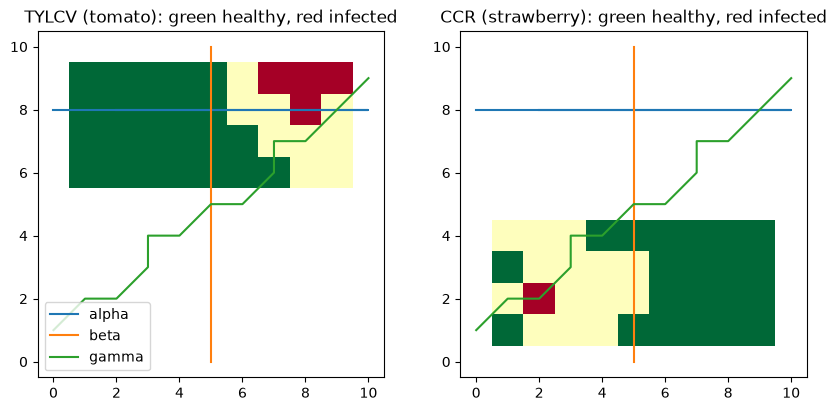

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))
for ax, title, value, mask in [(axes[0], "TYLCV (tomato)", environment.tylcv.value, environment.my_tomato_mask),
                               (axes[1], "CCR (strawberry)", environment.ccr.value, environment.my_strawberry_mask)]:
    ax.imshow(np.where(mask, value, np.nan).T, origin="lower", cmap="RdYlGn", vmin=0, vmax=1)
    for name in paths:
        positions = [obs for observations in results["observations"] for obs in observations if obs["robot"] == name]
        ax.plot([o["x"] for o in positions], [o["y"] for o in positions], label=name)
    ax.set_title(title + ": green healthy, red infected")
axes[0].legend(loc="lower left")
plt.show()

## The totals

`results["score-events"]` holds one event per timestep. The scalar components are the run totals at that point, and `"voi-credits"` holds the attribution rows. This is the last event:

In [4]:
last = results["score-events"][-1]
for variant in WBF_Score_VoI.VARIANTS:
    print(f"{variant:15s} {last['score'][variant]:8.1f}")
print("credit rows of the timestep-6 event:")
for row in results["score-events"][6]["score"]["voi-credits"]:
    print("   ", row)

voi-absolute      1212.0
voi-expected      2943.0
voi-ignorance     1068.0
voi-estimator     2416.0
credit rows of the timestep-6 event:
    {'variant': 'voi-absolute', 'robot': 'alpha', 'timestep': 6, 'value': np.float64(100.0)}
    {'variant': 'voi-ignorance', 'robot': 'alpha', 'timestep': 6, 'value': np.float64(103.0)}
    {'variant': 'voi-expected', 'robot': 'alpha', 'timestep': 6, 'value': np.float64(99.0)}
    {'variant': 'voi-estimator', 'robot': 'alpha', 'timestep': 6, 'value': np.float64(99.0)}
    {'variant': 'voi-absolute', 'robot': 'beta', 'timestep': 6, 'value': np.float64(1.0)}
    {'variant': 'voi-ignorance', 'robot': 'beta', 'timestep': 6, 'value': np.float64(4.0)}
    {'variant': 'voi-expected', 'robot': 'beta', 'timestep': 6, 'value': np.float64(0.0)}
    {'variant': 'voi-estimator', 'robot': 'beta', 'timestep': 6, 'value': np.float64(0.0)}
    {'variant': 'voi-absolute', 'robot': None, 'timestep': None, 'value': 0.0}
    {'variant': 'voi-ignorance', 'robot': None, 't

## VoI per robot

`voi_credits(results, variant)` gives, for every robot, the VoI it added at each timestep, plus the `None` row for the estimator update terms. Row totals compare the robots:

In [5]:
names = sorted(paths)
print(f"{'variant':15s}" + "".join(f"{name:>10s}" for name in names) + f"{'update':>10s}")
for variant in WBF_Score_VoI.VARIANTS:
    credits = voi_credits(results, variant)
    print(f"{variant:15s}" + "".join(f"{credits[name].sum():10.1f}" for name in names) + f"{credits[None].sum():10.1f}")

variant             alpha      beta     gamma    update
voi-absolute        405.0     205.0     602.0       0.0
voi-expected         99.0       0.0      99.0    2673.0
voi-ignorance       432.0     226.0     626.0       0.0
voi-estimator        99.0      99.0      99.0    2335.0


The `.cumsum()` of a row is that robot's accumulated VoI. Each panel shows one variant: one line per robot, the update terms (dashed), and their sum (black). The black line starts from 0, so it equals the variant's total minus its baseline, the value before any observation.

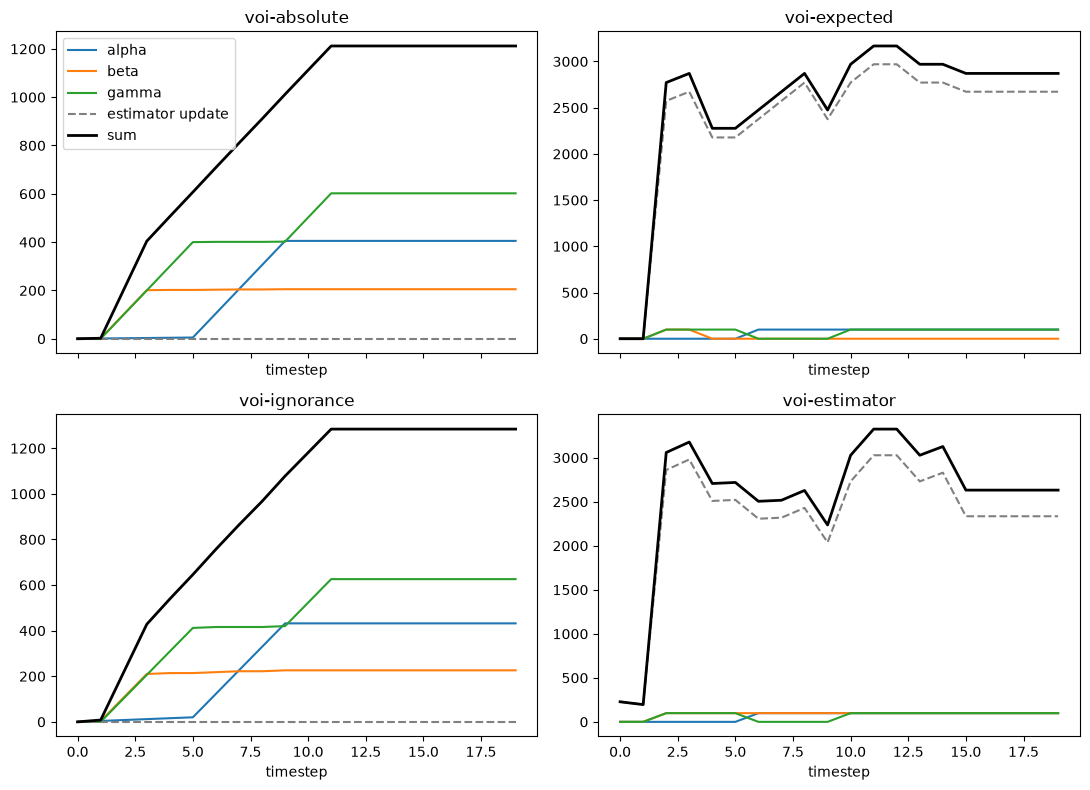

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(11, 8), sharex=True)
for ax, variant in zip(axes.flat, WBF_Score_VoI.VARIANTS):
    credits = voi_credits(results, variant)
    for name in names:
        ax.plot(credits[name].cumsum(), label=name)
    ax.plot(credits[None].cumsum(), "--", color="gray", label="estimator update")
    ax.plot(sum(credits.values()).cumsum(), color="black", linewidth=2, label="sum")
    ax.set_title(variant)
    ax.set_xlabel("timestep")
axes[0, 0].legend()
plt.tight_layout()
plt.show()

**Reading the panels:**
- **Absolute VoI and cost of ignorance** are credited entirely to the robots; the update term is 0. A step of +100 is a newly found infected cell, +1 a newly verified healthy one. Repeat observations add nothing, so alpha's line is flat on its way back.
- **Expected and estimator-based VoI** are dominated by the update term. The adaptive disk estimator paints each early observation over a large disk, so the estimate jumps at many cells at once, which the update term records. When a robot later observes such a cell, the belief was already there, so its discovery credit is small: `truth - expect_prev` is 0 if the disk had already predicted the right value. It is even negative when the disk had predicted an infection at a healthy cell: at timestep 6, gamma's expected-VoI credit is -99, because its observation corrected such an over-prediction.

## A per-timestep view

A robot's array shows exactly when its VoI was added. For alpha's absolute VoI:

In [7]:
alpha = voi_credits(results, "voi-absolute")["alpha"]
print({t: v for t, v in enumerate(alpha) if v != 0})
print("crossing (5,8):", estimator.record.first(5, 8), "observed", estimator.record.count(5, 8), "times")

{1: np.float64(1.0), 2: np.float64(1.0), 3: np.float64(1.0), 4: np.float64(1.0), 5: np.float64(1.0), 6: np.float64(100.0), 7: np.float64(100.0), 8: np.float64(100.0), 9: np.float64(100.0)}
crossing (5,8): ('alpha', 5) observed 3 times


## The invariant

For every variant and every event, the baseline plus all credits and update terms so far equals the total. The baseline is the score of an estimator with no observations.

In [8]:
baseline = WBF_Score_VoI(v_pos=100, v_neg=1, v_unknown=-3).score(environment, WBF_IM_DiskEstimator(farm.width, farm.height))
for variant in WBF_Score_VoI.VARIANTS:
    accumulated = sum(credits.sum() for credits in voi_credits(results, variant).values())
    print(f"{variant:15s} baseline {baseline[variant]:8.1f} + credits {accumulated:8.1f} = {baseline[variant] + accumulated:8.1f}"
          f"   total {last['score'][variant]:8.1f}")

voi-absolute    baseline      0.0 + credits   1212.0 =   1212.0   total   1212.0
voi-expected    baseline     72.0 + credits   2871.0 =   2943.0   total   2943.0
voi-ignorance   baseline   -216.0 + credits   1284.0 =   1068.0   total   1068.0
voi-estimator   baseline   -216.0 + credits   2632.0 =   2416.0   total   2416.0


## Without generalization, everything is credited to the robots

The update term measures the estimator's generalization. Even a disk of radius 1 still spreads every infected observation to its four neighbors, and robots moving along a line then step into cells that are already predicted. With a disk of radius 0 (a point estimate), an observation changes only its own cell. The update terms are then 0, and the expected and estimator-based VoI are credited entirely to the robots that make the discoveries. Absolute VoI and cost of ignorance do not depend on the estimator, so they are the same in all three runs.

In [9]:
for radius in [1, 0]:
    results_radius = run(WBF_IM_DiskEstimator(farm.width, farm.height, disk_radius=radius))
    print(f"disk radius {radius}")
    print(f"{'variant':15s}" + "".join(f"{name:>10s}" for name in names) + f"{'update':>10s}")
    for variant in WBF_Score_VoI.VARIANTS:
        credits = voi_credits(results_radius, variant)
        print(f"{variant:15s}" + "".join(f"{credits[name].sum():10.1f}" for name in names) + f"{credits[None].sum():10.1f}")
    print()

disk radius 1
variant             alpha      beta     gamma    update
voi-absolute        405.0     205.0     602.0       0.0
voi-expected         99.0       0.0     198.0    2376.0
voi-ignorance       432.0     226.0     626.0       0.0
voi-estimator        99.0       0.0     210.0    2481.0

disk radius 0
variant             alpha      beta     gamma    update
voi-absolute        405.0     205.0     602.0       0.0
voi-expected        396.0     198.0     594.0       0.0
voi-ignorance       432.0     226.0     626.0       0.0
voi-estimator       432.0     226.0     626.0       0.0

